In [1]:
# %% [markdown]
# ## MPC-Control Simulation and Data Analysis (CcaS/CcaR TCS)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
import warnings
warnings.filterwarnings("ignore")

from model_and_controller_equations.run_all_control_v7 import run_control
from model_and_controller_equations.run_constant import run_constant
from signal_analysis import analyze_signal

In [2]:
# %%
# Load experimental fluorescence datasets
data1 = pd.read_csv('experiment_data/P-FL_OD_run_data_042325.csv')
data2 = pd.read_csv('experiment_data/P-FL_OD_run_data_040625.csv')

# Extract experimental replicates
P1_data1 = data1[['SP1_1', 'SP1_2', 'SP1_3', 'SP1_4', 'SP1_5', 'SP1_6']].to_numpy()
P2_data1 = data1[['SP2_1', 'SP2_2', 'SP2_3', 'SP2_4', 'SP2_5', 'SP2_6']].to_numpy()

P1_data2 = data2[['SP1_1', 'SP1_2', 'SP1_3']].to_numpy()
P2_data2 = data2[['SP2_1', 'SP2_2', 'SP2_3']].to_numpy()

green_data1 = data1[['G1']].to_numpy()
green_data2 = data2[['G1', 'G2', 'G3']].to_numpy()
red_data1 = data1[['R1']].to_numpy()
red_data2 = data2[['R1', 'R2', 'R3']].to_numpy()

# Truncate all data to shared minimum length
min_len = min(P1_data1.shape[0], P1_data2.shape[0])
P1_data1 = P1_data1[:min_len]; P2_data1 = P2_data1[:min_len]
P1_data2 = P1_data2[:min_len]; P2_data2 = P2_data2[:min_len]
green_data1 = green_data1[:min_len]; green_data2 = green_data2[:min_len]
red_data1 = red_data1[:min_len]; red_data2 = red_data2[:min_len]


In [3]:
# %%
# Merge all experimental replicates
P1_all = np.hstack((P1_data1, P1_data2))
P2_all = np.hstack((P2_data1, P2_data2))
green_all = np.hstack((green_data1, green_data2))
red_all = np.hstack((red_data1, red_data2))

# Compute means and standard deviations
P1_mean = np.mean(P1_all, axis=1)
P1_std = np.std(P1_all, axis=1)
P2_mean = np.mean(P2_all, axis=1)
P2_std = np.std(P2_all, axis=1)
green_mean = np.mean(green_all, axis=1)
green_std = np.std(green_all, axis=1)
red_mean = np.mean(red_all, axis=1)
red_std = np.std(red_all, axis=1)


In [4]:
# %%
# Time parameters
interval = 10
time_exp = np.arange(interval, (min_len + 1) * interval, interval)
t_final = 16 * 60

# Setpoints from experiments
st_pt_1 = 11500
st_pt_2 = 18500

# Normalize scale using green max
green_max = np.max(green_mean)

# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#ebab4b',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'PID-GS': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'PID-GS-FF': '#03cea4'
}

# Normalize experimental data
P1_mean_norm = P1_mean / green_max
P1_std_norm = P1_std / green_max
P2_mean_norm = P2_mean / green_max
P2_std_norm = P2_std / green_max
green_mean_norm = green_mean / green_max
green_std_norm = green_std / green_max
red_mean_norm = red_mean / green_max
red_std_norm = red_std / green_max


In [5]:
# define model parameters 


p = pd.read_csv('parameters/TCS_params_guess_070225.csv').to_numpy()

p = p[:,2]

params = lmfit.Parameters()

params.add(name = 'k_green', value = p[0], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_red', value = p[1], min = 1e0, max = 1e4, vary = 1)
params.add(name = 'b_green', value = p[2], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'b_red', value = p[3], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'k_sp_b', value = p[4], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_sp_u', value = p[5], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'k_rp_b', value = p[6], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_rp_u', value = p[7], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'beta', value = p[8], min = 1e-1, max = 500, vary = 1)
params.add(name = 'l0', value = p[9], min = 0, max = 0.5, vary = 1)
params.add(name = 'Kc', value = p[10], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_m', value = p[11], min = 0.05, max = 0.35, vary = 1)
params.add(name = 'k_tl', value = p[12], min = 0.05, max = 10, vary = 1)
params.add(name = 'k_tli_b', value = p[13], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_tli_u', value = p[14], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_p', value = p[15], min = 1e-6, max = 1e-1, vary = 1)
params.add(name = 'k_fold', value = p[16], min = 0.05, max = 0.3, vary = 1)
params.add(name = 'b_fold', value = p[17], min = 0.1, max = 2, vary = 1)
params.add(name = 'n_gamma', value = p[18], min = 0.05, max = 0.9, vary = 1)
params.add(name = 'R_max', value = p[19], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'S_0', value = p[20], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'R_0', value = p[21], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Sp_0', value = p[22], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Rp_0', value = p[23], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'mRNA_0', value = p[24], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'P_0', value = p[25], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Pm_0', value = p[26], min = 1e-4, max = 1e4, vary = 1)


params.add(name = 'k_gr', value = p[27], vary = 0)
params.add(name = 'C_max', value = p[28], vary = 0)
params.add(name = 'C_0', value = p[29], vary = 0)

params.add(name = 'n_tcs', value = p[30], min = 0.1, max = 5, vary = 1)

# define initial conditions and solve the ODEs

x0 = np.zeros(11)

x0[0] = p[20] # S
x0[1] = p[22]# Sp
x0[2] = p[21] # R
x0[3] = p[23] # Rp
x0[4] = 0 # Ac
x0[5] = p[24] # mRNA
x0[6] = 0 # Ctic
x0[7] = p[25] # Unfolded Protein 
x0[8] = p[26] # Folded Protein 
x0[9] = p[29] # Initial Cell count
x0[10] = 0 # Initial Integral Error

t_final = 960

In [6]:
# Simulate constant inputs (open loop) without any disturbance for baseline measurement

time_green_no_perturbn, _, sol_green_no_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=0)
time_red_no_perturbn, _, sol_red_no_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=0)
time_dark_no_perturbn, _, sol_dark_no_perturbn = run_constant(t_final, x0, params, constant_input = 'dark', growth_perturb=0)

st_pt_1_model = st_pt_1 * (np.max(sol_green_no_perturbn[:,8]))/green_max
st_pt_2_model = st_pt_2 * (np.max(sol_green_no_perturbn[:,8]))/green_max

### Simulation of different controller stratgeies for disturbance rejection

In [7]:
# Controller parameters

# simulate the pre-run step
def closest_index(timepoints, target):
    tp = np.asarray(timepoints)
    i = np.searchsorted(tp, target, side="left")
    if i == 0:
        return 0
    if i == len(tp):
        return len(tp) - 1
    return i-1 if (target - tp[i-1]) <= (tp[i] - target) else i

t_rerun = 100
i_rerun = closest_index(time_green_no_perturbn, t_rerun)
x0 = sol_green_no_perturbn[i_rerun, :]


scaling_factor = (green_max/(np.max(sol_green_no_perturbn[:,8]))) * (1/60)

pid_gain = 0.032 * scaling_factor
FF_gain = 0.8 * scaling_factor
PID_FF_gain = 0.8 * scaling_factor

tolerence_percentage = 0.05 # 10%


# perturbation parameters
perturb_percent = 40 # If the sample is diluted by X%, the final OD equals the original (pre-dilution) OD multiplied by (100 − X)/100.
perturb_time = 480 # perturbation happens at this time
new_t_final = 16*60 # new experiment end time after perturbation


# Simulate constant inputs (open loop)
time_green_with_perturbn, _, sol_green_with_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)

time_red_with_perturbn, _, sol_red_with_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)


# Simulate disturbance rejection using Gain Scheduled PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS, ctrl_SP2_PID_to_PID_GS, sol_SP2_PID_to_PID_GS, t_green_on_SP2_PID_to_PID_GS,  opt_times_SP2_PID_to_PID_GS = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS",
                                                                print_perturb_message=True)

# Simulate disturbance rejection using plain Feed Forward (FF), with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_FF, ctrl_SP2_PID_to_FF, sol_SP2_PID_to_FF, t_green_on_SP2_PID_to_FF,  opt_times_SP2_PID_to_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="FF", FF_gain=FF_gain,
                                                                print_perturb_message=True)

# Simulate disturbance rejection using combined PID-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_FF, ctrl_SP2_PID_to_PID_FF, sol_SP2_PID_to_PID_FF, t_green_on_SP2_PID_to_PID_FF,  opt_times_SP2_PID_to_PID_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-FF", FF_gain=PID_FF_gain,
                                                                print_perturb_message=True)

# Simulate disturbance rejection using combined PID-GS-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS_FF, ctrl_SP2_PID_to_PID_GS_FF, sol_SP2_PID_to_PID_GS_FF, t_green_on_SP2_PID_to_PID_GS_FF,  opt_times_SP2_PID_to_PID_GS_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS-FF", FF_gain=PID_FF_gain,
                                                                print_perturb_message=True)


# Simulate disturbance rejection using plain PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID, ctrl_SP2_PID_to_PID, sol_SP2_PID_to_PID, t_green_on_SP2_PID_to_PID,  opt_times_SP2_PID_to_PID = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID",
                                                                print_perturb_message=True)

ctrl_SP2_PID_to_PID_norm = np.array(ctrl_SP2_PID_to_PID) / np.max(sol_green_no_perturbn[:,8])

Perturbing now
Perturbation applied at time 480 to bring to 172.94392523364485 minutes
Perturbing now
Perturbation applied at time 480 to bring to 172.94392523364485 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes


In [8]:
# Normalize simulation and experimental outputs
green_sim_norm = sol_green_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
red_sim_norm = sol_red_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_norm = np.array(ctrl_SP2_PID_to_PID_GS) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_FF_norm = np.array(ctrl_SP2_PID_to_FF) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_FF_norm = np.array(ctrl_SP2_PID_to_PID_FF) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_FF_norm = np.array(ctrl_SP2_PID_to_PID_GS_FF) / np.max(sol_green_no_perturbn[:,8])

dynamic_range_norm = np.max(sol_green_no_perturbn[:,8] - sol_red_no_perturbn[:,8])  / np.max(sol_green_no_perturbn[:,8])

time_extent = min((max(time_green_with_perturbn), max(time_red_with_perturbn), max(t_SP2_PID_to_PID_GS)))

# extract growth profiles 
growth_green_with_perturbn = sol_green_with_perturbn[:,9] 
growth_red_with_perturbn = sol_red_with_perturbn[:,9] 

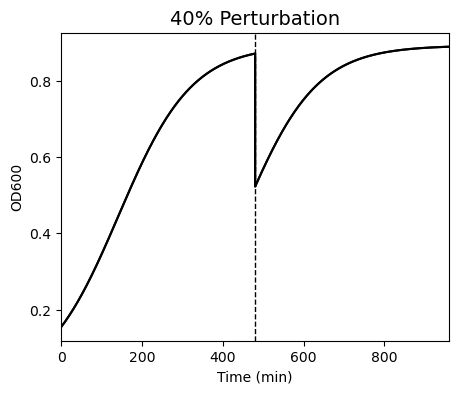

In [9]:
# Plot the growht perturbation 

fig, ax = plt.subplots(figsize=(5, 4))

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})
# Line width and alpha
lwd = 2
alp = 0.3

ax.plot(time_green_with_perturbn, growth_green_with_perturbn/8e8, 'k')
ax.plot(time_red_with_perturbn, growth_red_with_perturbn/8e8, 'k')
ax.set_xlabel('Time (min)')
ax.set_ylabel('OD600')
ax.set_xlim(0, time_extent)


ax.set_title(f"{perturb_percent}% Perturbation")

ax.axvline(x=perturb_time, color='black', linestyle='--', linewidth=1)

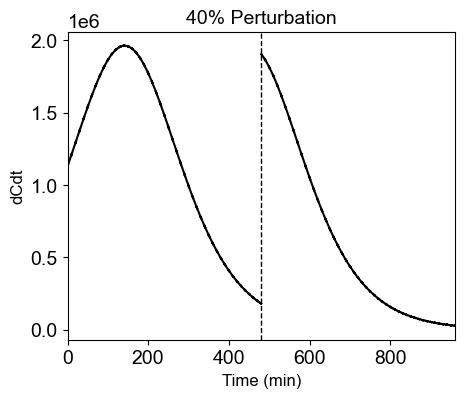

In [10]:
# Plot the growth rate perturbation 

dCdt = np.gradient(growth_green_with_perturbn, time_green_with_perturbn)

fig, ax = plt.subplots(figsize=(5, 4))

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})
# Line width and alpha
lwd = 2
alp = 0.3

ax.plot(time_green_with_perturbn, dCdt, 'k')
ax.set_xlabel('Time (min)')
ax.set_ylabel('dCdt')
ax.set_xlim(0, time_extent)


ax.set_title(f"{perturb_percent}% Perturbation")

ax.axvline(x=perturb_time, color='black', linestyle='--', linewidth=1)

In [11]:
def compute_performance_metric(ts_array, ITAE_array):
    """Computes a combined performance metric from settling times (ts) and ITAE.
    """
    ts = np.asarray(ts_array, dtype=float)
    itae = np.asarray(ITAE_array, dtype=float)

    if ts.shape != itae.shape:
        raise ValueError("ts_array and ITAE_array must have the same shape")
    
    min_perturb_time = 6 * 60 # the culture should grow for at least 6 hours before perturbation
     
    # itae max should be the integrated error if the system never settles within tolerence and we have a constant error equal to the tolerence band
    itae_max = tolerence_percentage * dynamic_range_norm * (new_t_final - min_perturb_time) * (new_t_final - min_perturb_time)/2
    ts_max = new_t_final - min_perturb_time
    # itae_max = 1e4
    # ts_max = 600

    ts_norm = ts/ts_max
    itae_norm = itae/itae_max

    metric = np.sqrt(ts_norm**2 + itae_norm**2)
    return metric

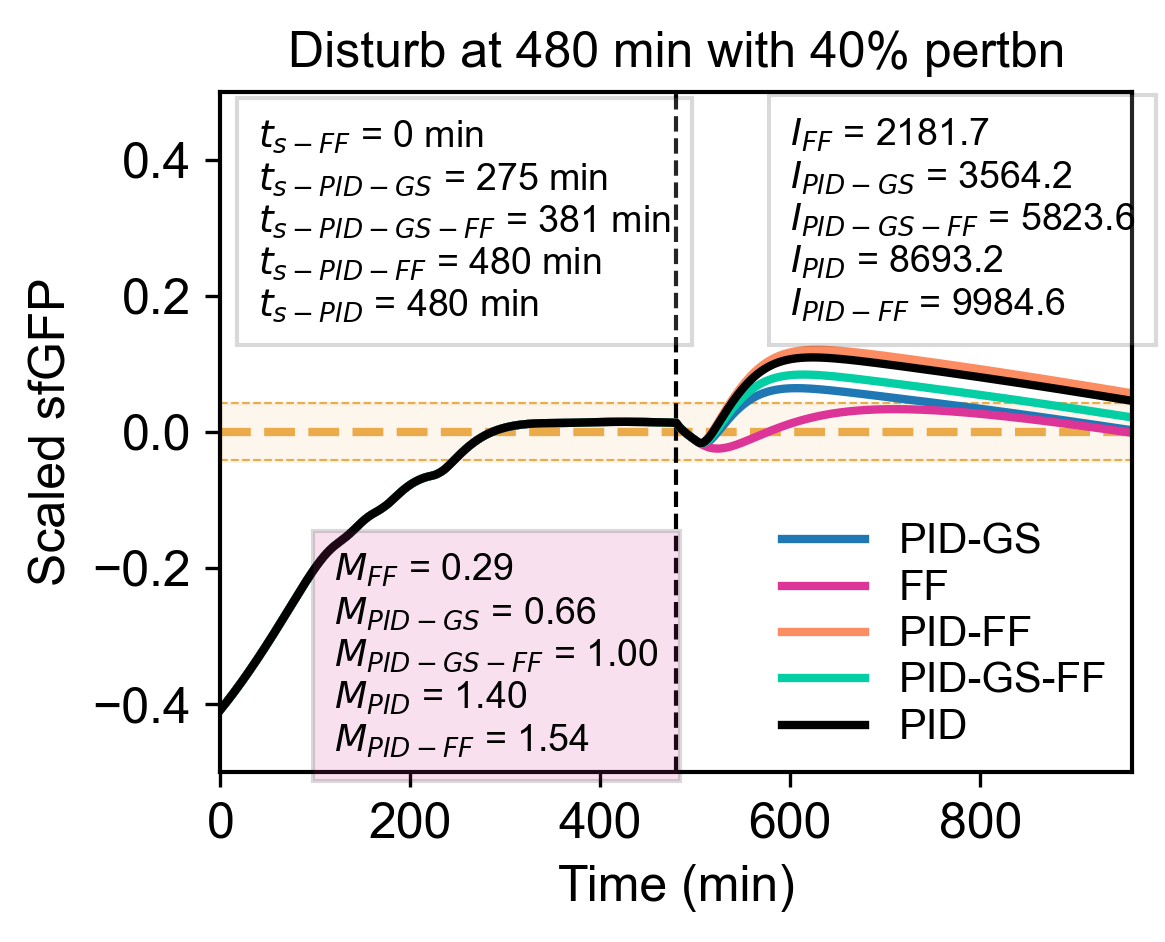

In [12]:
# plot the scaled disturbance 

# scaling is done as: (setpoint - signal)

fig, ax = plt.subplots(figsize=(4.2, 3.3), dpi=300)

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10
})

# Line width and alpha
lwd = 2
lwd_tol = 0.5
alp = 0.1

# Horizontal set points
ax.axhline(y=0, color=color_dict['set_point_2'], linestyle='--', linewidth=lwd)

# Tolerance bands (5%)
tol_band_norm = dynamic_range_norm * tolerence_percentage

upper_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * (st_pt_2 / green_max - st_pt_2 / green_max +  tol_band_norm)
lower_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * (st_pt_2 / green_max - st_pt_2 / green_max -  tol_band_norm)


ax.fill_between(t_SP2_PID_to_PID_GS, lower_tol_SP2, upper_tol_SP2, color=color_dict['set_point_2'], alpha=alp)
ax.axhline(y=st_pt_2 / green_max - st_pt_2 / green_max +  tol_band_norm, color=color_dict['set_point_2'], linestyle='--', linewidth=lwd_tol)
ax.axhline(y=st_pt_2 / green_max - st_pt_2 / green_max -  tol_band_norm, color=color_dict['set_point_2'], linestyle='--', linewidth=lwd_tol)

# vertical line to indicate time of pertubation 
ax.axvline(x=perturb_time, color='black', linestyle='--', linewidth=1)

# Model predictions
ax.plot(t_SP2_PID_to_PID_GS, ctrl_SP2_PID_to_PID_GS_norm - st_pt_2 / green_max, color=color_dict['PID-GS'], linewidth=lwd, label='PID-GS')
ax.plot(t_SP2_PID_to_FF, ctrl_SP2_PID_to_FF_norm - st_pt_2 / green_max, color=color_dict['FF'], linewidth=lwd, label='FF')
ax.plot(t_SP2_PID_to_PID_FF, ctrl_SP2_PID_to_PID_FF_norm - st_pt_2 / green_max, color=color_dict['PID-FF'], linewidth=lwd, label='PID-FF')
ax.plot(t_SP2_PID_to_PID_GS_FF, ctrl_SP2_PID_to_PID_GS_FF_norm - st_pt_2 / green_max, color=color_dict['PID-GS-FF'], linewidth=lwd, label='PID-GS-FF')
ax.plot(t_SP2_PID_to_PID, ctrl_SP2_PID_to_PID_norm - st_pt_2 / green_max, color=color_dict['PID'], linewidth=lwd, label='PID')


# Axes
ax.set_xlabel('Time (min)')
ax.set_ylabel('Scaled sfGFP')
ax.set_title(f"Disturb at {perturb_time} min with {perturb_percent}% pertbn")# + str(max_horizon_steps*10) + 'mins. SP1-' + str(np.round(elapsed_time_1,1)) + ' SP2-' + str(np.round(elapsed_time_2,1)))
ax.set_xlim(0, time_extent)
ax.set_ylim(-0.5, 0.5)

# Legend
ax.legend(loc='lower right',frameon=False, bbox_to_anchor=(1, 0), borderpad=0.1, labelspacing=0.2)


## Compute metrics:
rise_time_PID_to_PID_GS, settling_time_PID_to_PID_GS, overshoot_error_PID_to_PID_GS, ITAE_post_dist_PID_to_PID_GS = analyze_signal(ctrl_SP2_PID_to_PID_GS_norm - st_pt_2 / green_max, t_SP2_PID_to_PID_GS, st_pt_2 / green_max  - st_pt_2 / green_max,
                                                                    tol_band_norm, dynamic_range_norm, settle_time_cap=new_t_final, perturbed_time=perturb_time)

rise_time_PID_to_FF, settling_time_PID_to_FF, overshoot_error_PID_to_FF, ITAE_post_dist_PID_to_FF = analyze_signal(ctrl_SP2_PID_to_FF_norm - st_pt_2 / green_max, t_SP2_PID_to_FF, st_pt_2 / green_max  - st_pt_2 / green_max,
                                                                    tol_band_norm, dynamic_range_norm, settle_time_cap=new_t_final, perturbed_time=perturb_time)

rise_time_PID_to_PID_FF, settling_time_PID_to_PID_FF, overshoot_error_PID_to_PID_FF, ITAE_post_dist_PID_to_PID_FF = analyze_signal(ctrl_SP2_PID_to_PID_FF_norm - st_pt_2 / green_max, t_SP2_PID_to_PID_FF, st_pt_2 / green_max  - st_pt_2 / green_max,
                                                                    tol_band_norm, dynamic_range_norm, settle_time_cap=new_t_final, perturbed_time=perturb_time)

rise_time_PID_to_PID_GS_FF, settling_time_PID_to_PID_GS_FF, overshoot_error_PID_to_PID_GS_FF, ITAE_post_dist_PID_to_PID_GS_FF = analyze_signal(ctrl_SP2_PID_to_PID_GS_FF_norm - st_pt_2 / green_max, t_SP2_PID_to_PID_GS_FF, st_pt_2 / green_max  - st_pt_2 / green_max,
                                                                    tol_band_norm, dynamic_range_norm, settle_time_cap=new_t_final, perturbed_time=perturb_time)

rise_time_PID_to_PID, settling_time_PID_to_PID, overshoot_error_PID_to_PID, ITAE_post_dist_PID_to_PID = analyze_signal(ctrl_SP2_PID_to_PID_norm - st_pt_2 / green_max, t_SP2_PID_to_PID, st_pt_2 / green_max  - st_pt_2 / green_max,
                                                                    tol_band_norm, dynamic_range_norm, settle_time_cap=new_t_final, perturbed_time=perturb_time)

t_settle_PID_to_PID_GS = max(0, settling_time_PID_to_PID_GS - perturb_time)
t_settle_PID_to_FF = max(0, settling_time_PID_to_FF - perturb_time)
t_settle_PID_to_PID_FF = max(0, settling_time_PID_to_PID_FF - perturb_time)
t_settle_PID_to_PID_GS_FF = max(0, settling_time_PID_to_PID_GS_FF - perturb_time)
t_settle_PID_to_PID = max(0, settling_time_PID_to_PID - perturb_time)

ts_array = np.array([t_settle_PID_to_PID_GS, t_settle_PID_to_FF, t_settle_PID_to_PID_FF, t_settle_PID_to_PID_GS_FF, t_settle_PID_to_PID])
I_array = np.array([ITAE_post_dist_PID_to_PID_GS, ITAE_post_dist_PID_to_FF, ITAE_post_dist_PID_to_PID_FF, ITAE_post_dist_PID_to_PID_GS_FF, ITAE_post_dist_PID_to_PID])
metrics_array = compute_performance_metric(ts_array, I_array)


box_color = 'white'

# Adding a text box with customization
# Make a dictionary of settling time and labels
settling_times = [
    (r"$t_{s-PID-GS}$", t_settle_PID_to_PID_GS),
    (r"$t_{s-FF}$", t_settle_PID_to_FF),
    (r"$t_{s-PID-FF}$", t_settle_PID_to_PID_FF),
    (r"$t_{s-PID-GS-FF}$", t_settle_PID_to_PID_GS_FF),
    (r"$t_{s-PID}$", t_settle_PID_to_PID),
]

# Sort the settling times 
settling_times_sorted = sorted(settling_times, key=lambda x: x[1])

# Build the text box string
box_string = "\n".join(
    f"{label} = {value:.0f} min"
    for label, value in settling_times_sorted
)

text_box = ax.text(40, 0.17, box_string, fontsize=9,
                   bbox=dict(facecolor=box_color, alpha = 0.15, edgecolor='black', pad=5))

# Adding another text box with customization
# Make a dictionary of ITAE and labels
ITAE_all  = [
    (r"$I_{PID-GS}$", ITAE_post_dist_PID_to_PID_GS),
    (r"$I_{FF}$", ITAE_post_dist_PID_to_FF),
    (r"$I_{PID-FF}$", ITAE_post_dist_PID_to_PID_FF),
    (r"$I_{PID-GS-FF}$", ITAE_post_dist_PID_to_PID_GS_FF),
    (r"$I_{PID}$", ITAE_post_dist_PID_to_PID),
]

# Sort the ITAE 
ITAE_sorted = sorted(ITAE_all , key=lambda x: x[1])

# Build the text box string
box_string_ITAE = "\n".join(
    f"{label} = {value:.1f}"
    for label, value in ITAE_sorted
)

text_box_ITAE = ax.text(600, 0.17, box_string_ITAE, fontsize=9,
                   bbox=dict(facecolor=box_color, alpha = 0.15, edgecolor='black', pad=5))

# Adding another text box with customization
# Make a dictionary of metrics and labels
M_all  = [
    (r"$M_{PID-GS}$", metrics_array[0]),
    (r"$M_{FF}$", metrics_array[1]),
    (r"$M_{PID-FF}$", metrics_array[2]),
    (r"$M_{PID-GS-FF}$", metrics_array[3]),
    (r"$M_{PID}$", metrics_array[4]),
]

# Sort the metric
M_sorted = sorted(M_all , key=lambda x: x[1])

# Build the text box string
box_string_M = "\n".join(
    f"{label} = {value:.2f}"
    for label, value in M_sorted
)

# Set the box color based on the best controller
first_key = next(iter(M_sorted))[0]
start_id_controller_str = first_key.find("{") + 1
end_id_controller_str = first_key.find("}")
controller_id = first_key[start_id_controller_str:end_id_controller_str]

box_color = color_dict[controller_id]

text_box_M = ax.text(120, -0.47, box_string_M, fontsize=9,
                   bbox=dict(facecolor=box_color, alpha = 0.15, edgecolor='black', pad=5))

# Spine control
spine_width = 1.0
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(spine_width)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=12)


# Layout
fig.subplots_adjust(right=0.75)
plt.tight_layout()

# Save (if needed)
#plt.savefig('figures/p_control_model.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

In [13]:
# Preparing for the parameter sweep: 

results = []  # list of dict rows

controller_keys = ["PID-GS", "FF", "PID-FF", "PID-GS-FF", "PID"]

def safe_metric_after_disturbance(err, t, perturb_time, tol_band, dyn_range, settle_cap):
    rise_t, settle_t, overshoot, ITAE = analyze_signal(
        err, t,
        0.0,
        tol_band,
        dyn_range,
        settle_time_cap=settle_cap,
        perturbed_time=perturb_time
    )

    if settle_t is None or (isinstance(settle_t, float) and np.isnan(settle_t)):
        t_settle_after = np.inf
    else:
        t_settle_after = max(0.0, float(settle_t) - float(perturb_time))

    return {
        "rise_time": rise_t,
        "settling_time": settle_t,
        "t_settle_after": t_settle_after,
        "overshoot": overshoot,
        "ITAE": ITAE,
    }

In [14]:
# %%
# PID-only variation analysis across disturbance magnitudes

# -------------------------------
# User settings
# -------------------------------
perturb_time_var = 480          # min
perturb_percents = [20, 40, 60, 80]
new_t_final_var = 16 * 60       # min

# Colors for disturbance percentages
disturbance_colors = {
    20: '#98d9ea',
    40: '#6baed6',
    60: '#2171b5',
    80: '#08306b'
}

# -------------------------------
# Reuse existing normalization from earlier cells
# -------------------------------
norm_factor = np.max(sol_green_no_perturbn[:, 8])
setpoint_norm = st_pt_2 / green_max
dynamic_range_norm = np.max(sol_green_no_perturbn[:, 8] - sol_red_no_perturbn[:, 8]) / norm_factor
tol_band_norm = dynamic_range_norm * tolerence_percentage

# Make sure the PID simulations all start from the same initial condition
x0_pid = np.array(x0, dtype=float).copy()

# Store results here
pid_variation = {}

# -------------------------------
# Simulate PID disturbance rejection for each perturbation magnitude
# -------------------------------
for pp in perturb_percents:
    t_pid, ctrl_pid, sol_pid, t_green_on_pid, opt_times_pid = run_control(
        'PID-growth-perturb',
        t_final,
        st_pt_2_model,
        x0_pid.copy(),
        params,
        gain=pid_gain,
        perturb_percent=pp,
        perturb_time=perturb_time_var,
        new_t_final=new_t_final_var,
        initial_controller='PID',
        switch_to_controller='PID',
        print_perturb_message=False
    )

    pid_variation[pp] = {
        't': np.asarray(t_pid),
        'ctrl': np.asarray(ctrl_pid),
        'ctrl_norm': np.asarray(ctrl_pid) / norm_factor,
        'err': np.asarray(ctrl_pid) / norm_factor - setpoint_norm,
        'sol': np.asarray(sol_pid),
        't_green_on': np.asarray(t_green_on_pid),
        'opt_times': np.asarray(opt_times_pid)
    }

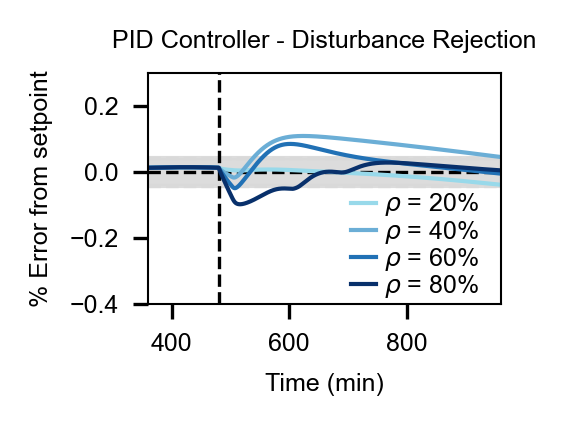

In [ ]:
# %%
# Plot 1: PID error-from-setpoint responses
# Fully customizable styling for this plot

plot1_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'zero_linewidth': 0.8,
    'tol_linewidth': 0.8,
    'perturb_linewidth': 0.8,
    'legend_loc': 'lower right',
    'tol_alpha': 0.90
}

plt.rcParams.update({
    'font.family': plot1_cfg['font_family'],
    'font.size': plot1_cfg['base_fontsize'],
    'axes.labelsize': plot1_cfg['label_fontsize'],
    'axes.titlesize': plot1_cfg['title_fontsize'],
    'legend.fontsize': plot1_cfg['legend_fontsize']
})

fig, ax = plt.subplots(figsize=plot1_cfg['figsize'], dpi=plot1_cfg['dpi'])

# Zero-error line and tolerance band
color_setpoint = '#d9d9d9'
ax.axhline(0.0, color='k', linestyle='--', linewidth=plot1_cfg['zero_linewidth'])
ax.fill_between(
    [0, new_t_final_var],
    [-tol_band_norm, -tol_band_norm],
    [tol_band_norm, tol_band_norm],
    color=color_setpoint,
    alpha=plot1_cfg['tol_alpha']
)
ax.axhline(+tol_band_norm, color=color_setpoint, linestyle='--', linewidth=plot1_cfg['tol_linewidth'])
ax.axhline(-tol_band_norm, color=color_setpoint, linestyle='--', linewidth=plot1_cfg['tol_linewidth'])

# Disturbance marker
ax.axvline(perturb_time_var, color='black', linestyle='--', linewidth=plot1_cfg['perturb_linewidth'])

# Plot PID error responses
for pp in perturb_percents:
    ax.plot(
        pid_variation[pp]['t'],
        pid_variation[pp]['err'],
        linewidth=plot1_cfg['line_width'],
        color=disturbance_colors[pp],
        label=rf"$\rho$ = {pp}%"
    )

ax.set_xlabel('Time (min)', fontsize=plot1_cfg['label_fontsize'])
ax.set_ylabel('% Error from setpoint', fontsize=plot1_cfg['label_fontsize'])
ax.set_title(f'PID Controller - Disturbance Rejection', fontsize=plot1_cfg['title_fontsize'])
ax.set_xlim(0, new_t_final_var)

all_err = np.concatenate([pid_variation[pp]['err'] for pp in perturb_percents])
ymax = max(np.max(np.abs(all_err)), tol_band_norm) * 1.15
# ax.set_ylim(-ymax, ymax)
ax.set_ylim(-0.4, 0.3)
ax.set_xlim(360, 960)

ax.legend(frameon=False, loc=plot1_cfg['legend_loc'], fontsize=plot1_cfg['legend_fontsize'],
          ncol=1, columnspacing=0.3, labelspacing=0.01, handlelength=1, handletextpad=0.3,
          bbox_to_anchor=(1,-0.08))

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(plot1_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=plot1_cfg['tick_fontsize'])
plt.tight_layout()
#fig.set_facecolor('white')
#plt.savefig('figures/pid_perturbation_varying_percents.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig('figures/pid_perturbation_varying_percents_with_legend.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

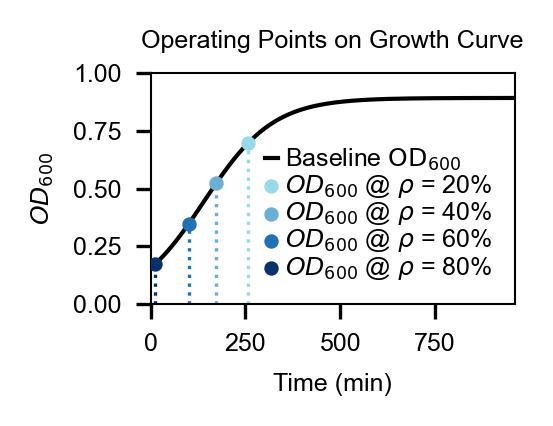

In [16]:
# %%
# Plot 2: Baseline growth curve with annotated perturbation levels
# Fully customizable styling for this plot

plot2_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'curve_linewidth': 1,
    'guide_linewidth': 0.8,
    'match_linewidth': 0.6,
    'drop_linewidth': 0.8,
    'perturb_linewidth': 0.8,
    'axis_linewidth': 0.5,
    'scatter_size_main': 6,
    'scatter_size_match': 6,
    'annotation_fontsize': 6,
    'legend_loc': 'lower right',
    'x_text_offset': 40
}

plt.rcParams.update({
    'font.family': plot2_cfg['font_family'],
    'font.size': plot2_cfg['base_fontsize'],
    'axes.labelsize': plot2_cfg['label_fontsize'],
    'axes.titlesize': plot2_cfg['title_fontsize'],
    'legend.fontsize': plot2_cfg['legend_fontsize']
})

time_growth_ref, _, sol_growth_ref = run_constant(
    t_final,
    x0_pid.copy(),
    params,
    constant_input='green',
    growth_perturb=0
)

growth_ref_od = sol_growth_ref[:, 9] / 8e8
od_pre = np.interp(perturb_time_var, time_growth_ref, growth_ref_od)

fig, ax = plt.subplots(figsize=plot2_cfg['figsize'], dpi=plot2_cfg['dpi'])

# Baseline growth curve
ax.plot(
    time_growth_ref,
    growth_ref_od,
    color='black',
    linewidth=plot2_cfg['curve_linewidth'],
    label=r'Baseline $\mathrm{OD}_{600}$'
)

# For monotonic growth, invert OD -> time using interpolation
baseline_time_from_od = lambda od_val: np.interp(od_val, growth_ref_od, time_growth_ref)

x_text = perturb_time_var + plot2_cfg['x_text_offset']

for pp in perturb_percents:
    od_post = od_pre * (1 - pp / 100.0)
    t_match = baseline_time_from_od(od_post)

    # Mark the corresponding point on the baseline curve
    ax.scatter(
        t_match,
        od_post,
        color=disturbance_colors[pp],
        s=plot2_cfg['scatter_size_match'],
        zorder=6,
        label=rf'$OD_{{600}}$ @ $\rho$ = {pp}%'
    )

    # Vertical line from x-axis to the matched point on the growth curve
    ax.vlines(
        t_match,
        0,
        od_post,
        colors=disturbance_colors[pp],
        linestyles=':',
        linewidth=plot2_cfg['guide_linewidth']
    )

ax.set_xlabel('Time (min)', fontsize=plot2_cfg['label_fontsize'])
ax.set_ylabel('$OD_{600}$', fontsize=plot2_cfg['label_fontsize'])
ax.set_title(r'Operating Points on Growth Curve', fontsize=plot2_cfg['title_fontsize'])
ax.set_xlim(0, new_t_final_var)
ax.set_ylim(0, 1)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(plot2_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=plot2_cfg['tick_fontsize'])
ax.legend(frameon=False, loc=plot2_cfg['legend_loc'], fontsize=plot2_cfg['legend_fontsize'],
          ncol=1, columnspacing=0.3, labelspacing=0.01, handlelength=0.5, handletextpad=0.3)
plt.tight_layout()
#plt.savefig('figures/operating_ODs.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)